In [1]:
import imaplib
import email
from email.header import decode_header
import os
import pdfplumber
import pandas as pd

from nltk import Text

from konlpy.tag import Komoran
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
IMAP_SERVER = "imap.gmail.com"
EMAIL = "jeonchanhyeog074@gmail.com"
PASSWORD = "heke cpas sftb sycn"
SAVE_DIR = "./downloads"
os.makedirs(SAVE_DIR, exist_ok=True)
# 1. IMAP 접속
mail = imaplib.IMAP4_SSL(IMAP_SERVER)
mail.login(EMAIL, PASSWORD)
mail.select("inbox")

('OK', [b'2638'])

In [3]:
# 1. 최근 10개 메일만 확인
result, data = mail.search(None, "ALL")
mail_ids = data[0].split()[-10:]

target_mail_ids = []

for mail_id in reversed(mail_ids):
    result, data = mail.fetch(
        mail_id,
        "(BODY.PEEK[HEADER.FIELDS (SUBJECT)])"
    )

    raw_header = data[0][1]
    msg = email.message_from_bytes(raw_header)

    subject_header = msg.get("Subject", "")
    subject = ""
    for part, encoding in decode_header(subject_header):
        if isinstance(part, bytes):
            subject += part.decode(encoding or "utf-8", errors="replace")
        else:
            subject += part

    if "[업무협조]" in subject:
        print("대상 메일:", subject)
        target_mail_ids.append(mail_id)

if target_mail_ids is None:
    print("조건에 맞는 메일 없음")

대상 메일: [업무협조]ㅇㅁㄴㅇㅁㄴ
대상 메일: [업무협조]ㅇㄴㅇ


In [4]:
# 2. 조건에 맞는 메일만 전체 가져오기
for target_mail_id in target_mail_ids:
    result, data = mail.fetch(target_mail_id, "(RFC822)")

    if result != "OK":
        print("메일 가져오기 실패")
    else:
        raw_email = data[0][1]
        target_mail = email.message_from_bytes(raw_email)

# PDF

In [6]:
pdf_files = []

for target_mail_id in target_mail_ids:
    result, data = mail.fetch(target_mail_id, "(RFC822)")

    if result != "OK":
        print("메일 가져오기 실패:", target_mail_id)
        continue

    raw_email = data[0][1]
    target_mail = email.message_from_bytes(raw_email)

    for part in target_mail.walk():
        content_disposition = part.get("Content-Disposition")

        if content_disposition and "attachment" in content_disposition:
            filename = part.get_filename()

            if filename:
                filename, enc = decode_header(filename)[0]
                if isinstance(filename, bytes):
                    filename = filename.decode(enc or "utf-8", errors="replace")

                if filename.lower().endswith(".pdf"):
                    filepath = os.path.join(SAVE_DIR, filename)

                    with open(filepath, "wb") as f:
                        f.write(part.get_payload(decode=True))

                    print("다운로드 완료:", filepath)
                    pdf_files.append(filepath)


다운로드 완료: ./downloads\sample-local-pdf.pdf
다운로드 완료: ./downloads\전찬혁-preprocessing.pdf


In [7]:
def pdfs_to_df(pdf_files):
    rows = []

    for pdf_path in pdf_files:
        full_text = ""

        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text += text + "\n"

        rows.append({
            "title": os.path.basename(pdf_path),
            "content": full_text.strip()
        })

    df = pd.DataFrame(rows)
    return df


In [8]:
def add_nouns_column(df):
    komoran = Komoran()

    df = df.copy()
    df["nouns"] = df["content"].apply(
        lambda x: [noun for noun in komoran.nouns(x) if len(noun) >= 2]
    )
    return df



In [9]:
def add_document_column(df):
    df = df.copy()
    df["document"] = df["nouns"].apply(lambda nouns: " ".join(nouns))
    return df


In [10]:
def get_tfidf_keywords(df, top_n=10):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(df["document"])

    feature_names = vectorizer.get_feature_names_out()
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=df["title"])

    top_keywords = []
    for title in tfidf_df.index:
        top_series = tfidf_df.loc[title].sort_values(ascending=False).head(top_n)
        top_keywords.append({
            "title": title,
            "keywords": list(top_series.index),
            "scores": list(top_series.values)
        })

    keyword_df = pd.DataFrame(top_keywords)
    return tfidf_df, keyword_df, vectorizer, tfidf_matrix



In [ ]:
pdf_text_df = pdfs_to_df(pdf_files)
pdf_nouns_df = add_nouns_column(pdf_text_df)
pdf_nouns_df = add_document_column(pdf_nouns_df)

# tfidf_df, keyword_df, vectorizer, tfidf_matrix = get_tfidf_keywords(pdf_nouns_document_df, top_n=10)

all_nouns = [noun for nouns in pdf_nouns_df["nouns"] for noun in nouns]

print
text = Text(all_nouns)

In [12]:
from matplotlib import font_manager, rc
font_fname	='c:/windows/fonts/gulim.ttc'
font_name = font_manager.FontProperties(fname=font_fname).get_name()
rc('font', family = font_name)

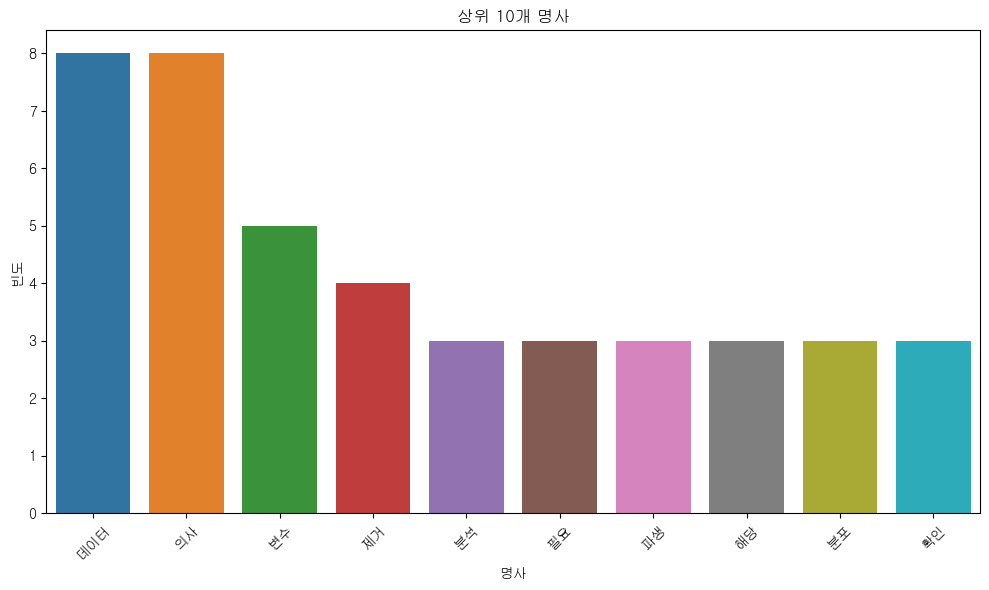

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

top10_df = pd.DataFrame(text.vocab().most_common(10), columns=["noun", "count"])

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_df, x="noun", y="count", hue="noun", legend=False)
plt.title("상위 10개 명사")
plt.xlabel("명사")
plt.ylabel("빈도")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='Samples', ylabel='Counts'>

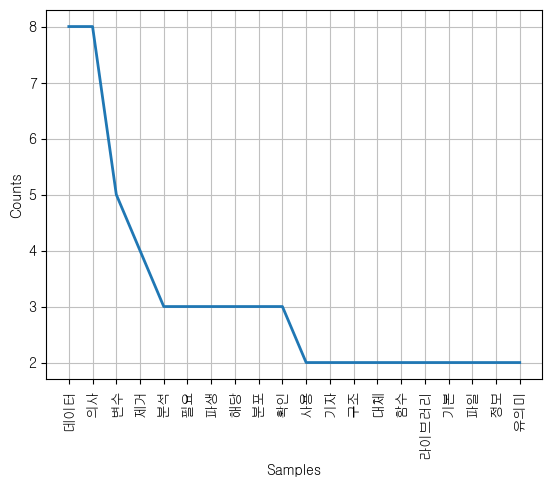

In [13]:
text.plot(20)

In [22]:
for i in pdf_nouns_df['document']:
    print(type(i))

<class 'str'>


In [27]:
from wordcloud import WordCloud

wordc = WordCloud(background_color='white',relative_scaling=0.2,font_path=r'C:\Windows\Fonts\malgun.ttf')
wordc_list = []
for i in pdf_nouns_df['document']:
    wordc_list.append(wordc.generate(i))

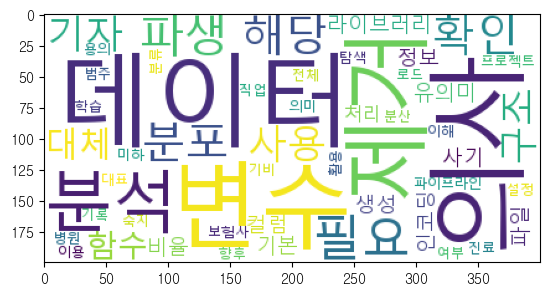

In [28]:
import matplotlib.pyplot as plt
plt.imshow(wordc_list[0])
plt.show()